In [35]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_selector import Data_selector
from feature_adder import Feature_adder
from feature_selector import Feature_selector
from logs.logger import CustomLogger
from models import Random_Forest, Linear, Polynomial, XGBoost, LinearL1
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

logger = CustomLogger(name="model_main", log_file_name='model_main.log').get_logger()
from main import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [65]:
number_mimo = 1
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 3
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)

ds = Data_selector(df)
df_modified = ds.select_peaks(goodness=3)

feature_selector = Feature_selector(df_modified, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season"] + ["datetime"]
feature_selector.select(features_to_select=features_to_be_select)
df = feature_selector.df
code = "G11"
name = "پرند"
mask = (df["name"] == name) & (df['code'] == code)
df = df[mask]

In [66]:
target = "generation"
dff = pd.DataFrame(df, index=df["datetime"])

In [67]:
# تقسیم داده
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"تعداد داده‌های آموزش: {len(train)}")
print(f"تعداد داده‌های تست: {len(test)}")

تعداد داده‌های آموزش: 3767
تعداد داده‌های تست: 942


In [76]:
# تعریف پارامترهای SARIMA
# SARIMA(p, d, q)(P, D, Q, s)
p, d, q = 1, 1, 1          # پارامترهای غیر فصلی
P, D, Q, s = 1, 1, 1, 12   # پارامترهای فصلی (s=12 برای داده ماهانه)

cc = ["temperature", "humidity", "dew", "surface_pressure", "forecast"]
# آموزش مدل
model = SARIMAX(train["generation"],
                exog=train[cc],
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         generation   No. Observations:                 3767
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -7663.947
Date:                            Mon, 15 Sep 2025   AIC                          15347.894
Time:                                    17:58:38   BIC                          15410.162
Sample:                                         0   HQIC                         15370.042
                                           - 3767                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
temperature          0.0171      0.011      1.505      0.132      -0.005       0.039
humidity         

MAE: 8.44
MSE: 109.27
RMSE: 10.45


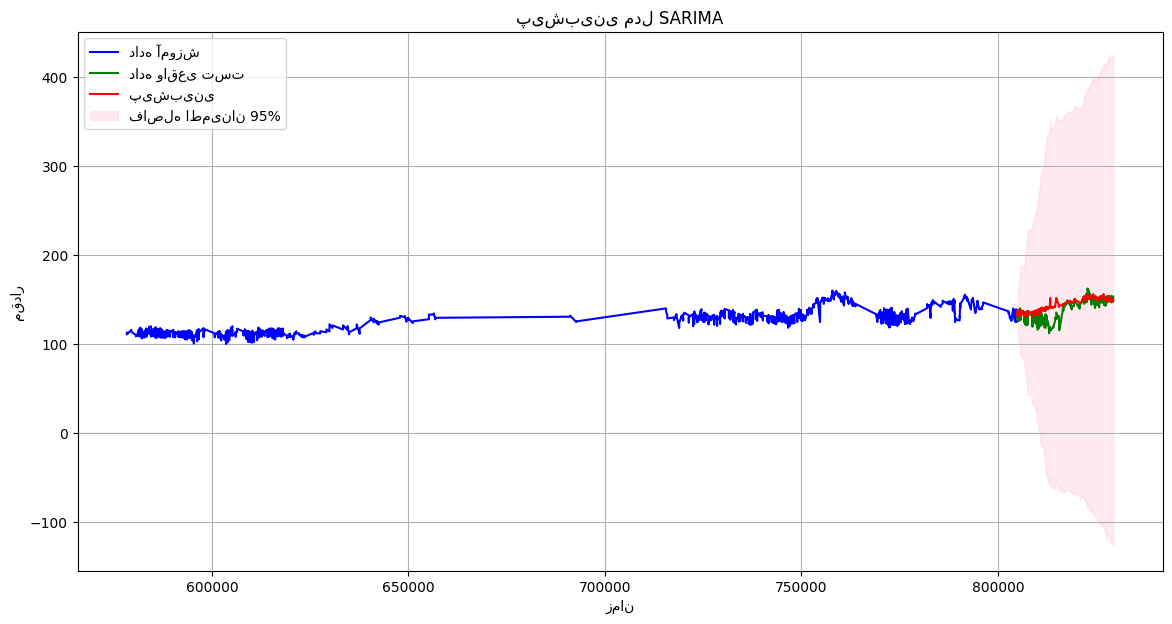

In [78]:
# پیش‌بینی
forecast_steps = len(test)
forecast = results.get_forecast(
        steps=forecast_steps,
        exog=test[cc]  # متغیرهای برونزاد برای دوره پیش‌بینی
    )
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# محاسبه معیارهای ارزیابی
mae = mean_absolute_error(test[target], forecast_mean)
mse = mean_squared_error(test[target], forecast_mean)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# نمایش نتایج
plt.figure(figsize=(14, 7))
plt.plot(train.index, train[target], label='داده آموزش', color='blue')
plt.plot(test.index, test[target], label='داده واقعی تست', color='green')
plt.plot(test.index, forecast_mean, label='پیش‌بینی', color='red')
plt.fill_between(test.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='فاصله اطمینان 95%')
plt.title('پیش‌بینی مدل SARIMA')
plt.xlabel('زمان')
plt.ylabel('مقدار')
plt.legend()
plt.grid(True)
plt.show()

In [80]:
from pmdarima import auto_arima

# استفاده از auto_arima برای تشخیص خودکار پارامترها
auto_model = auto_arima(df[target],
                        exog=df[cc],
                        seasonal=True,
                        m=12,  # دوره فصلی
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print(auto_model.summary())

# پیش‌بینی با مدل بهینه
auto_forecast = auto_model.predict(n_periods=len(test))

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=7.34 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=20035.853, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=19956.991, Time=0.62 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=19966.291, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=20033.937, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=19976.980, Time=0.12 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=19955.297, Time=2.15 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=19960.991, Time=2.45 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=19945.231, Time=1.78 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=19957.760, Time=0.56 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=19829.531, Time=7.93 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=19959.477, Time=2.08 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=19828.013, Time=9.33 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=19921.809, Time=8.55 sec
 ARIMA(2,1,

MemoryError: Unable to allocate 11.6 MiB for an array with shape (18, 18, 4709) and data type float64

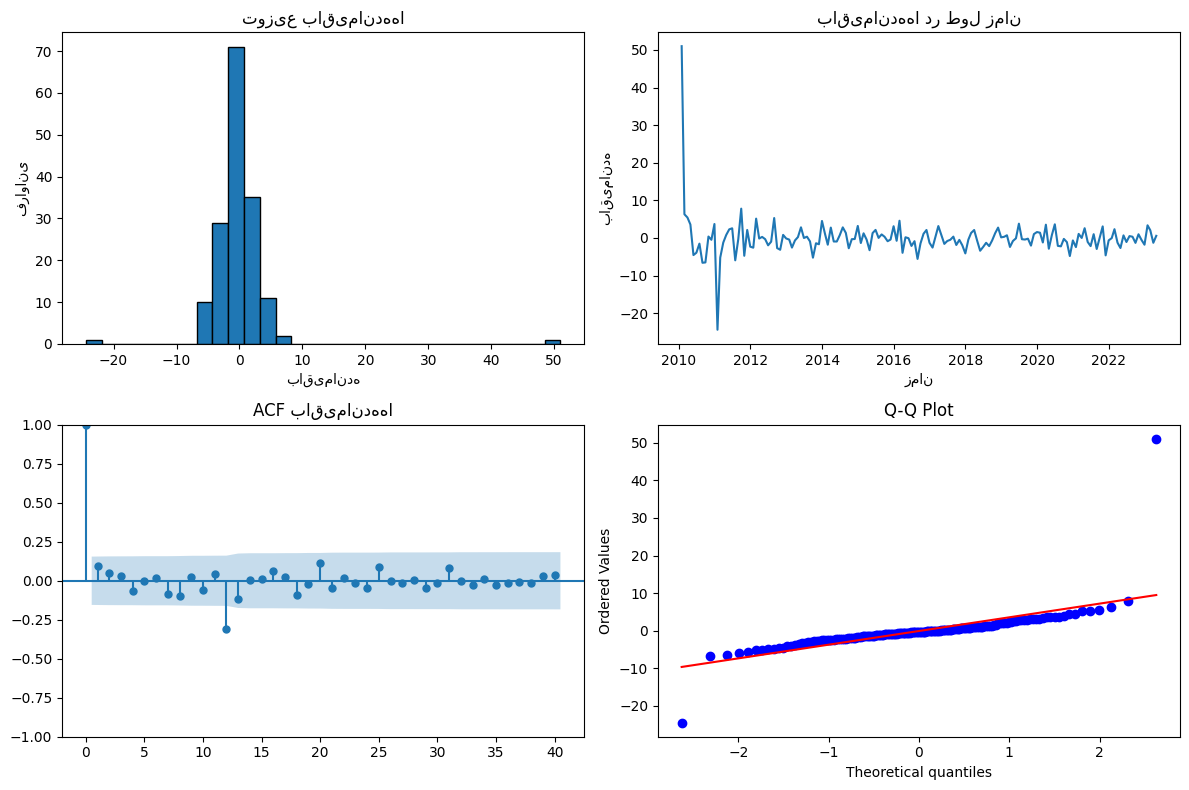

In [30]:
# تحلیل باقیمانده‌ها
residuals = results.resid

plt.figure(figsize=(12, 8))

# توزیع باقیمانده‌ها
plt.subplot(2, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('توزیع باقیمانده‌ها')
plt.xlabel('باقیمانده')
plt.ylabel('فراوانی')

# باقیمانده‌ها در زمان
plt.subplot(2, 2, 2)
plt.plot(residuals)
plt.title('باقیمانده‌ها در طول زمان')
plt.xlabel('زمان')
plt.ylabel('باقیمانده')

# ACF باقیمانده‌ها
plt.subplot(2, 2, 3)
plot_acf(residuals, lags=40, ax=plt.gca())
plt.title('ACF باقیمانده‌ها')

# Q-Q Plot
plt.subplot(2, 2, 4)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

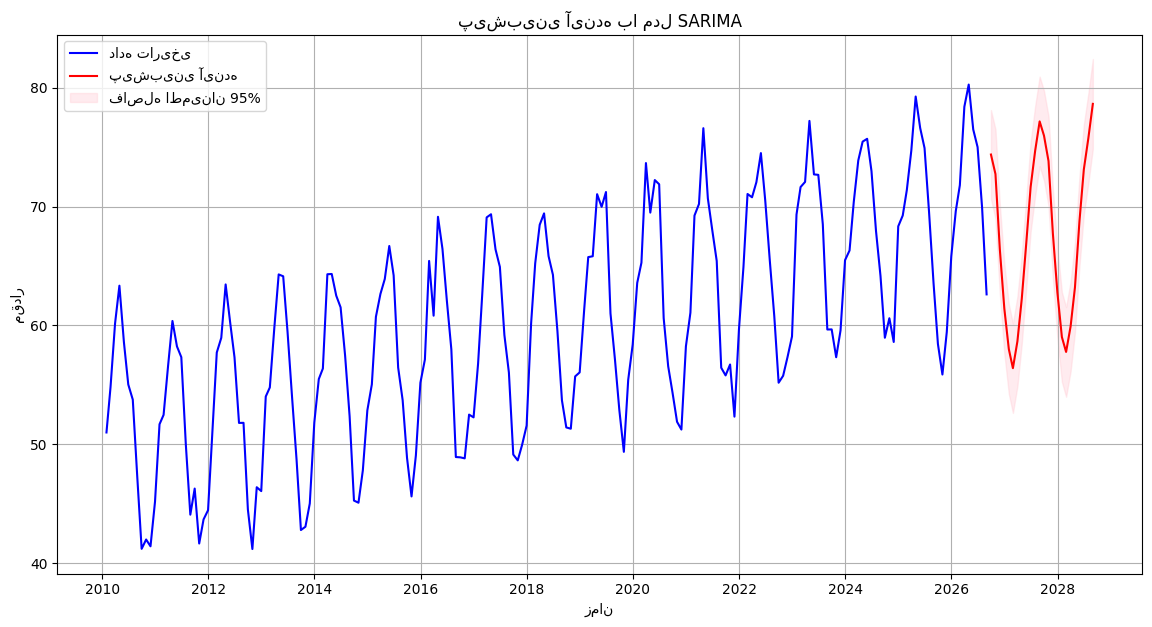

In [ ]:
# پیش‌بینی برای آینده
future_steps = 24
future_forecast = results.get_forecast(steps=future_steps)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

# ایجاد ایندکس برای آینده
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1),
                            periods=future_steps,
                            freq='M')

plt.figure(figsize=(14, 7))
plt.plot(df.index, df[target], label='داده تاریخی', color='blue')
plt.plot(future_dates, future_mean, label='پیش‌بینی آینده', color='red')
plt.fill_between(future_dates,
                 future_ci.iloc[:, 0],
                 future_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='فاصله اطمینان 95%')
plt.title('پیش‌بینی آینده با مدل SARIMA')
plt.xlabel('زمان')
plt.ylabel('مقدار')
plt.legend()
plt.grid(True)
plt.show()